Loading Parquet file...
Original dataset dimensions: (7728394, 46)
Dimensions after sampling: (1000000, 46)
Dimensions after removing leakage: (1000000, 42)

Severity Distribution:
           Count  Percentage (%)
Severity                        
1           8785          0.8785
2         796174         79.6174
3         168475         16.8475
4          26566          2.6566


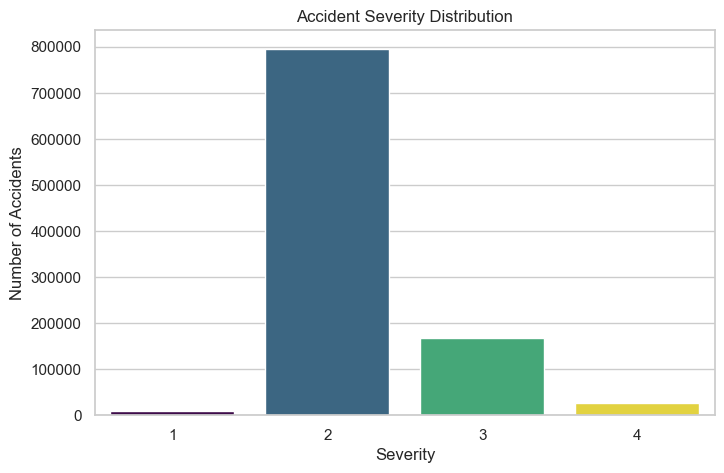

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Load the dataset in Parquet format
file_path = '../data/raw/US_accidents_dataset.parquet' 

print("Loading Parquet file...")
df = pd.read_parquet(file_path, engine='pyarrow')

print(f"Original dataset dimensions: {df.shape}")

# Sample 1 million rows for faster iteration (if the dataset is larger)
if len(df) > 1000000:
    df = df.sample(n=1000000, random_state=42).reset_index(drop=True)
    print(f"Dimensions after sampling: {df.shape}")

# 2. Remove Data Leakage columns and ID
# Note: we use errors='ignore' in case any of these are missing
leakage_cols = ['End_Time', 'Distance(mi)', 'Description']
id_cols = ['ID']

df = df.drop(columns=leakage_cols + id_cols, errors='ignore')

print(f"Dimensions after removing leakage: {df.shape}")

# 3. Target Variable (Severity) Analysis
severity_counts = df['Severity'].value_counts().sort_index()
severity_pct = df['Severity'].value_counts(normalize=True).sort_index() * 100

target_analysis = pd.DataFrame({
    'Count': severity_counts,
    'Percentage (%)': severity_pct
})
print("\nSeverity Distribution:")
print(target_analysis)

# Visualization
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='Severity', 
    hue='Severity', 
    palette='viridis', 
    legend=False
)
plt.title('Accident Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Number of Accidents')
plt.show()

In [10]:
# 1. Binary Target Creation
# Set critical accidents (Severity == 4) to 1, and all others to 0
df['Is_Severe'] = (df['Severity'] == 4).astype(int)

# We can now drop the old multiclass column
df = df.drop(columns=['Severity'])

print("Distribution of the new binary target (Is_Severe):")
print(df['Is_Severe'].value_counts(normalize=True) * 100)
print("-" * 30)

# 2. Temporal Feature Engineering
print("Extracting temporal features...")

# Convert Start_Time to datetime format (this might take a few seconds)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')

# Extract useful information for the model
df['Hour'] = df['Start_Time'].dt.hour
df['DayOfWeek'] = df['Start_Time'].dt.dayofweek # 0 = Monday, 6 = Sunday
df['Month'] = df['Start_Time'].dt.month

# Create a boolean feature for the weekend (Saturday=5, Sunday=6)
df['Is_Weekend'] = (df['DayOfWeek'] >= 5).astype(int)

# Now that we have extracted the core data, the original Start_Time column is no longer needed
df = df.drop(columns=['Start_Time'])

print("Temporal features extracted successfully!")
print(f"New dataset dimensions: {df.shape}")

# Let's take a look at the first few rows of the new features
display(df[['Is_Severe', 'Hour', 'DayOfWeek', 'Month', 'Is_Weekend']].head())

Distribution of the new binary target (Is_Severe):
Is_Severe
0    97.3434
1     2.6566
Name: proportion, dtype: float64
------------------------------
Extracting temporal features...
Temporal features extracted successfully!
New dataset dimensions: (1000000, 45)


,Is_Severe,Hour,DayOfWeek,Month,Is_Weekend
0,0,9.0,4.0,4.0,0
1,0,NaN,NaN,NaN,0
2,0,16.0,4.0,8.0,0
3,0,15.0,4.0,9.0,0
4,0,16.0,0.0,6.0,0


Dropped 96016 rows due to missing timestamps.
Current dataset dimensions: (903984, 45)
------------------------------
Percentage of missing values per column:
End_Lat                  48.744447
End_Lng                  48.744447
Precipitation(in)        31.141480
Wind_Chill(F)            28.282470
Wind_Speed(mph)           7.913304
Visibility(mi)            2.259221
Weather_Condition         2.223823
Humidity(%)               2.214088
Wind_Direction            2.208667
Temperature(F)            2.084771
Pressure(in)              1.789080
Weather_Timestamp         1.516730
Airport_Code              0.269363
Sunrise_Sunset            0.262283
Civil_Twilight            0.262283
Nautical_Twilight         0.262283
Astronomical_Twilight     0.262283
Street                    0.121684
Timezone                  0.094692
Zipcode                   0.023120
City                      0.003540
dtype: float64


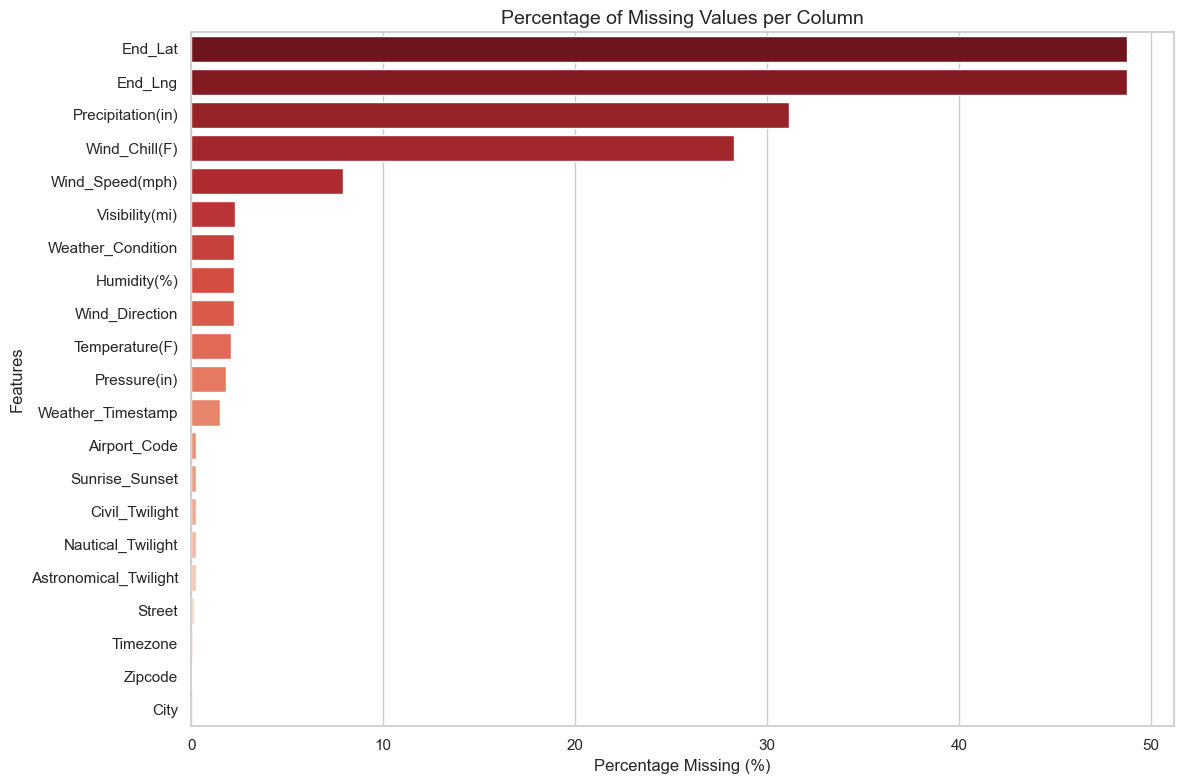

In [11]:
# 1. Drop rows missing critical temporal data
# If we don't know when the accident happened, the record is unreliable
initial_rows = len(df)
df = df.dropna(subset=['Hour', 'DayOfWeek', 'Month'])
rows_dropped = initial_rows - len(df)

print(f"Dropped {rows_dropped} rows due to missing timestamps.")
print(f"Current dataset dimensions: {df.shape}")
print("-" * 30)

# 2. Calculate missing value percentages for all columns
missing_data = df.isnull().sum()
missing_percentages = (missing_data / len(df)) * 100

# Filter only columns that actually have missing values and sort them
missing_percentages = missing_percentages[missing_percentages > 0].sort_values(ascending=False)

print("Percentage of missing values per column:")
print(missing_percentages)

# 3. Visualize the missing data (Great for your thesis report!)
import matplotlib.pyplot as plt
import seaborn as sns

if not missing_percentages.empty:
    plt.figure(figsize=(12, 8))
    # Using hue and legend=False to avoid the Seaborn deprecation warning you saw earlier
    sns.barplot(
        x=missing_percentages.values, 
        y=missing_percentages.index, 
        hue=missing_percentages.index, 
        palette='Reds_r', 
        legend=False
    )
    plt.title('Percentage of Missing Values per Column', fontsize=14)
    plt.xlabel('Percentage Missing (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values left in the dataset!")

In [12]:
# 1. Drop columns with massive missing values, leakage, or excessively granular data
cols_to_drop = [
    'End_Lat', 'End_Lng', 'Wind_Chill(F)', 'Airport_Code', 
    'Weather_Timestamp', 'Zipcode', 'Street', 'Timezone'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

# 2. Handle Precipitation (Domain knowledge: NaN often means 0 inches of rain)
df['Precipitation(in)'] = df['Precipitation(in)'].fillna(0)

# 3. Impute remaining numeric columns with the Median (robust to outliers)
numeric_cols = [
    'Wind_Speed(mph)', 'Visibility(mi)', 'Humidity(%)', 
    'Temperature(F)', 'Pressure(in)'
]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# 4. Impute categorical columns with the Mode (most frequent value)
categorical_cols = [
    'Weather_Condition', 'Wind_Direction', 'Sunrise_Sunset', 
    'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight', 'City'
]
for col in categorical_cols:
    # mode()[0] takes the most frequent value
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled successfully!")
print(f"Remaining missing values in the entire dataset: {df.isnull().sum().sum()}")
print(f"Final dataset dimensions ready for encoding: {df.shape}")

Missing values handled successfully!
Remaining missing values in the entire dataset: 0
Final dataset dimensions ready for encoding: (903984, 37)


In [13]:
from sklearn.preprocessing import LabelEncoder

print("Starting categorical encoding...")

# 1. Convert boolean columns to integers (True/False -> 1/0)
bool_cols = [col for col in df.columns if df[col].dtype == bool]
for col in bool_cols:
    df[col] = df[col].astype(int)
    
print(f"Converted {len(bool_cols)} boolean columns to integers.")

# 2. Convert object/string columns using Label Encoding
# This is highly efficient for tree-based machine learning models
object_cols = df.select_dtypes(include=['object']).columns

le = LabelEncoder()
for col in object_cols:
    # Cast to string first to prevent any hidden mixed-type errors
    df[col] = le.fit_transform(df[col].astype(str))

print(f"Encoded {len(object_cols)} categorical string columns.")
print("-" * 30)

print("Encoding completed successfully!")
print(f"Final dataset dimensions: {df.shape}")
print("All features are now numeric matrices, ready for ML algorithms.")

# Let's verify the final state of the data
display(df.info())

Starting categorical encoding...
Converted 13 boolean columns to integers.


/var/folders/g9/f1rnpnn13_x0cvwt2s88243c0000gn/T/ipykernel_69721/374046268.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = df.select_dtypes(include=['object']).columns


Encoded 11 categorical string columns.
------------------------------
Encoding completed successfully!
Final dataset dimensions: (903984, 37)
All features are now numeric matrices, ready for ML algorithms.
<class 'pandas.DataFrame'>
Index: 903984 entries, 0 to 999999
Data columns (total 37 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Source                 903984 non-null  int64  
 1   Start_Lat              903984 non-null  float64
 2   Start_Lng              903984 non-null  float64
 3   City                   903984 non-null  int64  
 4   County                 903984 non-null  int64  
 5   State                  903984 non-null  int64  
 6   Country                903984 non-null  int64  
 7   Temperature(F)         903984 non-null  float64
 8   Humidity(%)            903984 non-null  float64
 9   Pressure(in)           903984 non-null  float64
 10  Visibility(mi)         903984 non-null  float64
 11  Wind_

None

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

print("Splitting data into train and test sets...")

# Separate features (X) and target variable (y)
X = df.drop(columns=['Is_Severe'])
y = df['Is_Severe']

# Standard 80/20 split. 
# stratify=y is necessary because the target is highly imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Random Forest Classifier...")

# Initialize Random Forest
# class_weight='balanced' helps the model pay attention to the rare severe accidents
# max_depth=15 prevents the tree from growing too deep and overfitting the training data
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Fit the model
rf_model.fit(X_train, y_train)

print("Training completed. Generating predictions...")

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the results
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Splitting data into train and test sets...
Training Random Forest Classifier...
Training completed. Generating predictions...

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91    176017
           1       0.11      0.71      0.18      4780

    accuracy                           0.83    180797
   macro avg       0.55      0.77      0.55    180797
weighted avg       0.97      0.83      0.89    180797



Extracting Feature Importances from the Random Forest...

Top 5 Most Important Features:
        Feature  Importance
0        Source    0.328740
2     Start_Lng    0.109962
1     Start_Lat    0.104013
5         State    0.077426
9  Pressure(in)    0.047875


/var/folders/g9/f1rnpnn13_x0cvwt2s88243c0000gn/T/ipykernel_69721/1260886539.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


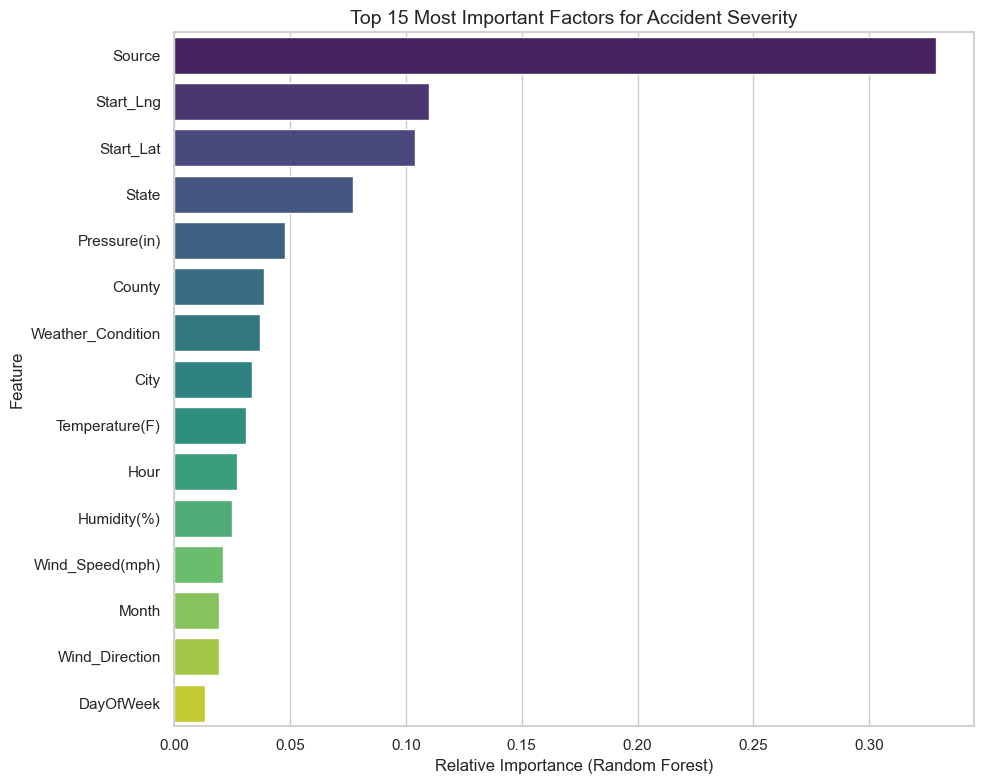

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Extracting Feature Importances from the Random Forest...")

# Extract importances from the model
importances = rf_model.feature_importances_

# Create a DataFrame to hold the feature names and their importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort the DataFrame by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Select the top 15 most important features to avoid visual clutter
top_15_features = feature_importance_df.head(15)

print("\nTop 5 Most Important Features:")
print(top_15_features.head())

# Plotting the feature importances
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_15_features, 
    palette='viridis'
)

plt.title('Top 15 Most Important Factors for Accident Severity', fontsize=14)
plt.xlabel('Relative Importance (Random Forest)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()